In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report


In [4]:
df=pd.read_csv('train.csv')

In [5]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [6]:
df.shape

(1460, 81)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [8]:
drop_cols=['Id','Alley','PoolQC','MiscFeature']
df.drop(drop_cols,axis=1,inplace=True)

In [9]:
df.isnull().sum().sort_values(ascending=False)

Fence            1179
MasVnrType        872
FireplaceQu       690
LotFrontage       259
GarageFinish       81
                 ... 
MoSold              0
YrSold              0
SaleType            0
SaleCondition       0
SalePrice           0
Length: 77, dtype: int64

In [10]:
df.drop(['Fence','MasVnrType','LotFrontage','FireplaceQu'],axis=1,inplace=True)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 73 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotArea        1460 non-null   int64  
 3   Street         1460 non-null   object 
 4   LotShape       1460 non-null   object 
 5   LandContour    1460 non-null   object 
 6   Utilities      1460 non-null   object 
 7   LotConfig      1460 non-null   object 
 8   LandSlope      1460 non-null   object 
 9   Neighborhood   1460 non-null   object 
 10  Condition1     1460 non-null   object 
 11  Condition2     1460 non-null   object 
 12  BldgType       1460 non-null   object 
 13  HouseStyle     1460 non-null   object 
 14  OverallQual    1460 non-null   int64  
 15  OverallCond    1460 non-null   int64  
 16  YearBuilt      1460 non-null   int64  
 17  YearRemodAdd   1460 non-null   int64  
 18  RoofStyl

In [12]:
df.isnull().sum().sort_values(ascending=False)

GarageQual       81
GarageCond       81
GarageType       81
GarageYrBlt      81
GarageFinish     81
                 ..
MoSold            0
YrSold            0
SaleType          0
SaleCondition     0
SalePrice         0
Length: 73, dtype: int64

In [13]:
df['GarageQual'].unique()

array(['TA', 'Fa', 'Gd', nan, 'Ex', 'Po'], dtype=object)

In [14]:
df['GarageQual']=df['GarageQual'].fillna(df['GarageQual'].mode()[0])

In [15]:
df['Electrical']=df['Electrical'].fillna(df['Electrical'].mode()[0])

In [16]:
col_to_change=df.columns[df.isnull().sum() > 0]
categorical_col_tofill=df[col_to_change].select_dtypes(include=['object', 'string']).columns
numerical_col_tofill=df[col_to_change].select_dtypes(include=['float64', 'int64']).columns


In [17]:
df[categorical_col_tofill] = df[categorical_col_tofill].fillna(df[categorical_col_tofill].mode().iloc[0])
for col in numerical_col_tofill:
    df[col] = df[col].fillna(df[col].median())

In [18]:
df.isnull().sum().sort_values(ascending=False)

#now we filled all nul values

MSSubClass       0
MSZoning         0
LotArea          0
Street           0
LotShape         0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 73, dtype: int64

In [19]:
df.head()

,MSSubClass,MSZoning,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,20,RL,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,60,RL,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,70,RL,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,60,RL,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,...,0,0,0,0,0,12,2008,WD,Normal,250000


In [20]:
df['SaleCondition'].value_counts()

SaleCondition
Normal     1198
Partial     125
Abnorml     101
Family       20
Alloca       12
AdjLand       4
Name: count, dtype: int64

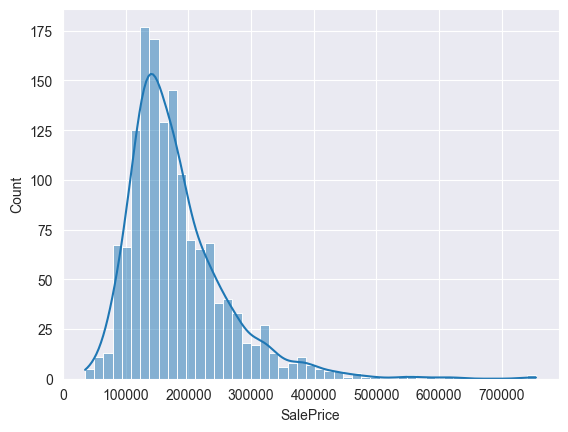

In [21]:
sns.histplot(data=df,x='SalePrice',kde=True)
plt.show()

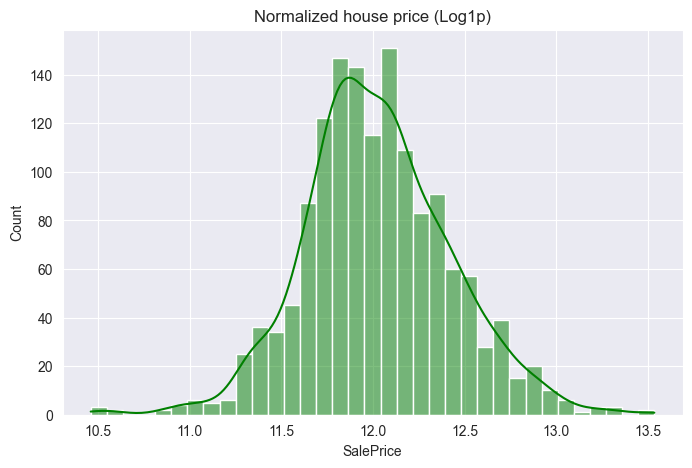

In [22]:
# !! İmportante
df['SalePrice'] = np.log1p(df['SalePrice'])

# Yeni ve Normalleşmiş Hali
plt.figure(figsize=(8,5))
sns.histplot(df['SalePrice'], kde=True, color='green')
plt.title("Normalized house price (Log1p)")
plt.show()

In [23]:
df = pd.get_dummies(df, drop_first=True)

In [24]:
df.head()

,MSSubClass,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,8450,7,5,2003,2003,196.0,706,0,150,...,False,False,False,False,True,False,False,False,True,False
1,20,9600,6,8,1976,1976,0.0,978,0,284,...,False,False,False,False,True,False,False,False,True,False
2,60,11250,7,5,2001,2002,162.0,486,0,434,...,False,False,False,False,True,False,False,False,True,False
3,70,9550,7,5,1915,1970,0.0,216,0,540,...,False,False,False,False,True,False,False,False,False,False
4,60,14260,8,5,2000,2000,350.0,655,0,490,...,False,False,False,False,True,False,False,False,True,False


In [25]:
X=df.drop('SalePrice',axis=1)
y=df['SalePrice']

In [26]:
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=15)

In [27]:
from sklearn.preprocessing import RobustScaler
robust=RobustScaler()
X_train=robust.fit_transform(X_train)
X_test=robust.transform(X_test)

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, r2_score ,root_mean_squared_error

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

models = {
    "KNN": Pipeline([("scaler", StandardScaler()), ("model", KNeighborsRegressor())]),
    "SVR": Pipeline([("scaler", StandardScaler()), ("model", SVR())]),
    "LinearRegression": LinearRegression(),
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "RandomForest": RandomForestRegressor(random_state=42),
    "AdaBoost": AdaBoostRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42),
    "LightGBM": LGBMRegressor(random_state=42, verbose=-1)
}

In [30]:
for name, model in models.items():

    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    rmse=root_mean_squared_error(y_test,y_pred)
    r2=r2_score(y_test,y_pred)
    print(f"{name} - rmse :{rmse} - r2:{r2}")


KNN - rmse :0.20546872290353602 - r2:0.7298552856531639
SVR - rmse :0.17392527942134467 - r2:0.8064333869964042
LinearRegression - rmse :0.20095965187543655 - r2:0.7415819941205843
DecisionTree - rmse :0.18596421445944417 - r2:0.7787089796571893
RandomForest - rmse :0.1371211039667371 - r2:0.8796867014729308
AdaBoost - rmse :0.16443472782487187 - r2:0.8269816687295879
XGBoost - rmse :0.13307663598577812 - r2:0.8866794537776481
LightGBM - rmse :0.11982141771377239 - r2:0.9081299528998377


C:\Users\Monster\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [31]:
# we find results and we saw lightgbm is the top model now we try hyperparameter tuning

In [32]:
lgbm = LGBMRegressor(random_state=42, verbose=-1)

In [33]:
param_grid = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [31, 50, 70]
}

In [34]:
grid_search = GridSearchCV(lgbm, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

,estimator,"LGBMRegressor...2, verbose=-1)"
,param_grid,"{'learning_rate': [0.01, 0.05, ...], 'n_estimators': [100, 300, ...], 'num_leaves': [31, 50, ...]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,boosting_type,'gbdt'


In [35]:
best_lgbm = grid_search.best_estimator_

In [36]:
y_pred_tuned = best_lgbm.predict(X_test)

C:\Users\Monster\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [37]:
print(f"--- 🏆 Best params ---")
print(grid_search.best_params_)
print(f"New R2 Score: {r2_score(y_test, y_pred_tuned):.4f}")

--- 🏆 Best params ---
{'learning_rate': 0.01, 'n_estimators': 500, 'num_leaves': 31}
New R2 Score: 0.9063


In [38]:
importances = best_lgbm.feature_importances_

In [39]:
X_train_df=pd.DataFrame(X_train)

In [40]:
orijinal_columns= X.columns

In [41]:
importance_df = pd.DataFrame({'Feature': orijinal_columns, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(10)

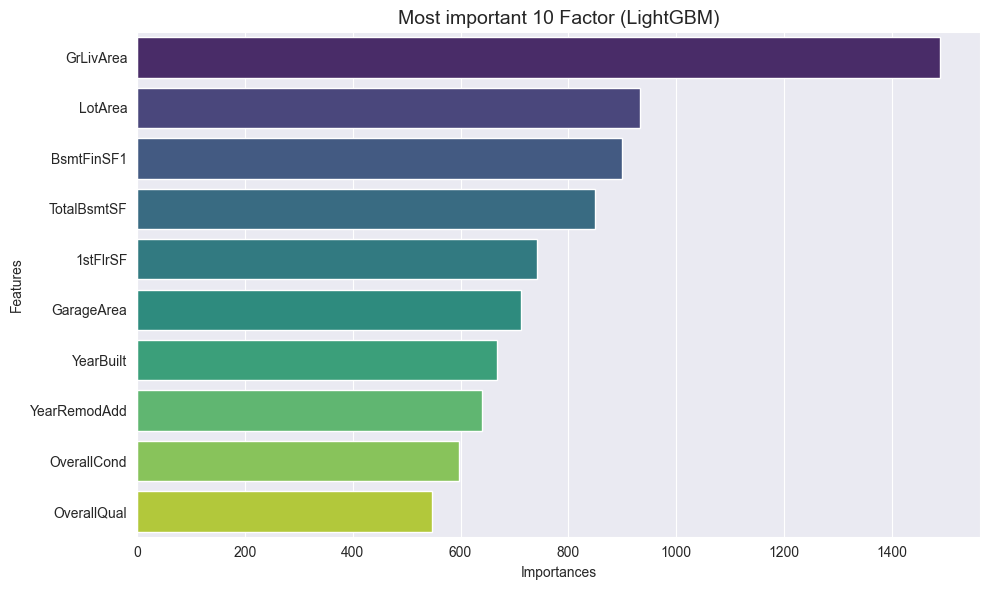

In [42]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, hue='Feature', palette='viridis', legend=False)
plt.title('Most important 10 Factor (LightGBM)', fontsize=14)
plt.xlabel('Importances')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [43]:
import shap

In [44]:
explainer = shap.TreeExplainer(best_lgbm)

In [45]:
shap_values = explainer.shap_values(X_test)

In [46]:
X_test_df = pd.DataFrame(X_test, columns=X.columns)

In [47]:
X_test_df = pd.DataFrame(X_test, columns=X.columns)

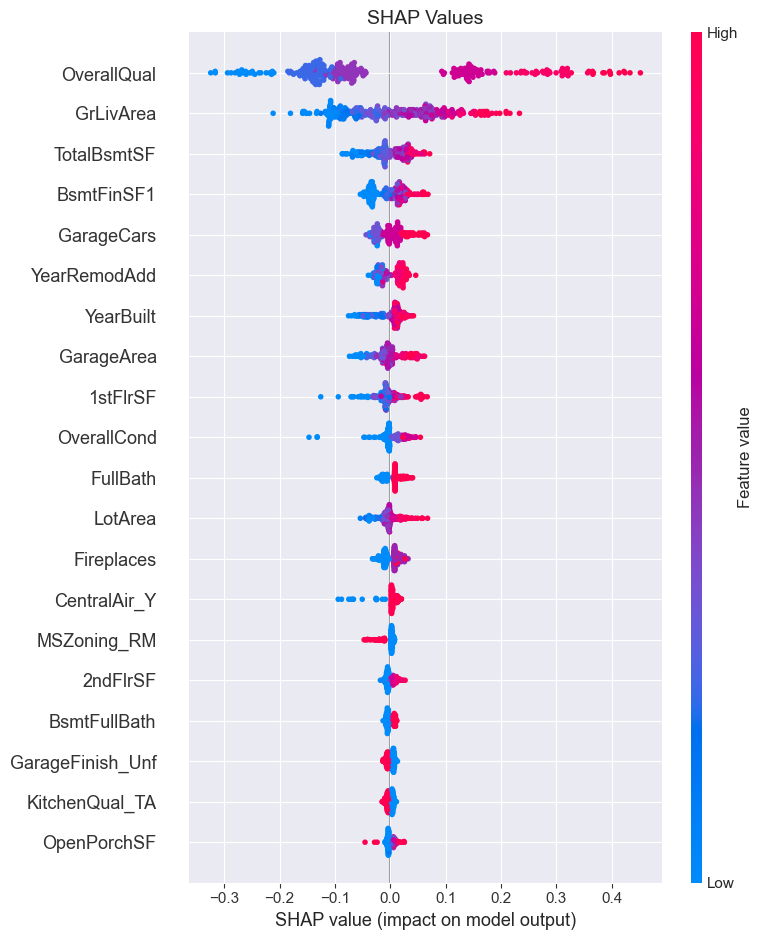

In [48]:
plt.title("SHAP Values", fontsize=14)
shap.summary_plot(shap_values, X_test_df)